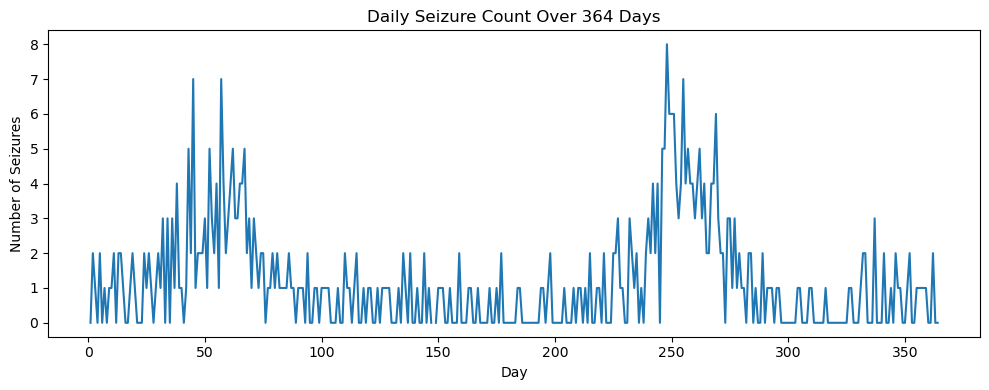

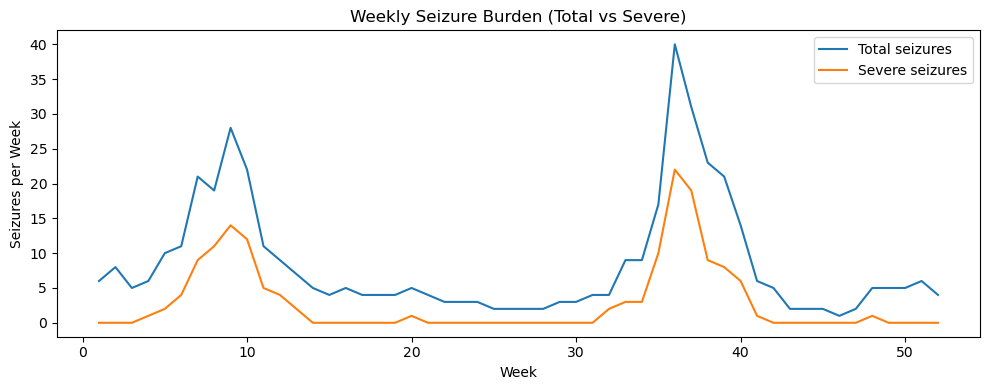

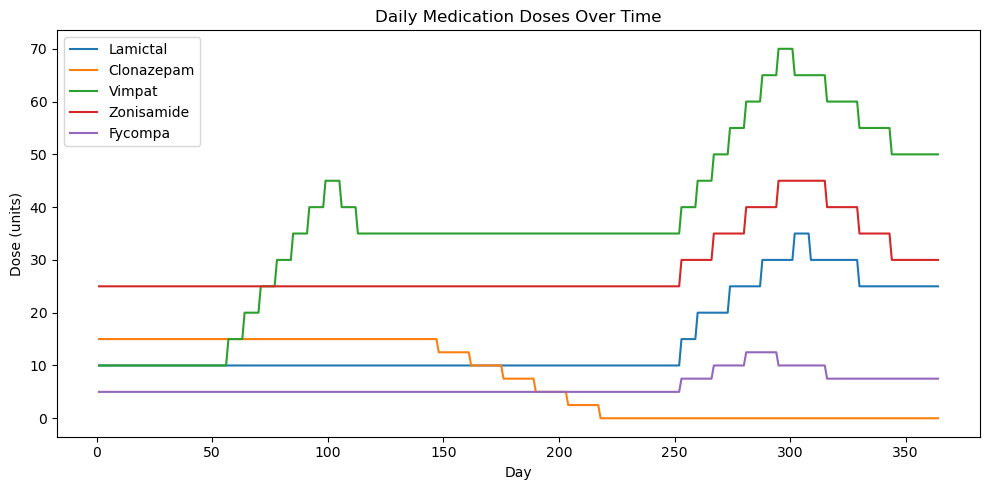

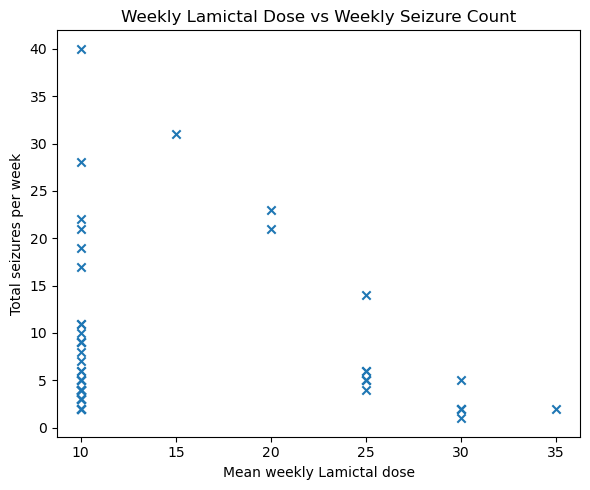

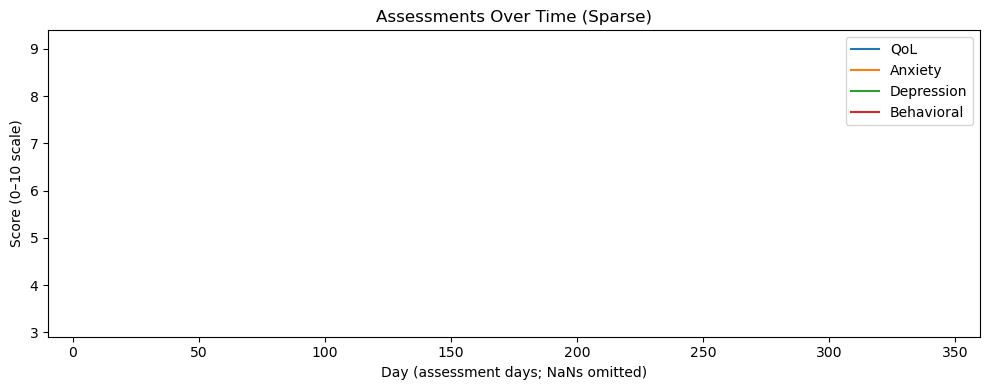

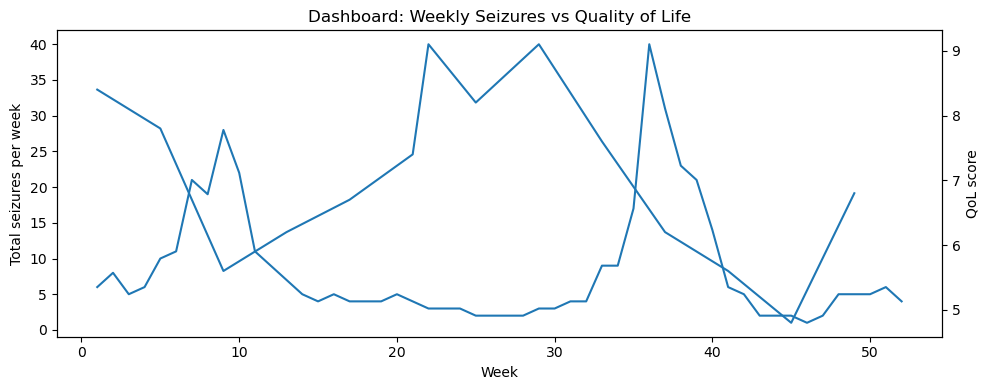

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 0. LOAD DATA
# ------------------------------------------------------------------
path = "52 week Dashboard.xlsx"   # adjust path if needed
df = pd.read_excel(path, sheet_name=0, header=None)

# ------------------------------------------------------------------
# 1. BASIC STRUCTURE: DAYS & WEEKS
# ------------------------------------------------------------------

# Row with "Day#" under seizure events
day_row_idx = df.index[df[0] == "Day#"][0]
# Day numbers live in columns 1..N
day_numbers = df.loc[day_row_idx, 1:].astype(float)
num_days = int(day_numbers.count())
days = np.arange(1, num_days + 1)

# Row with "Week#"
week_row_idx = df.index[df[0] == "Week#"][0]
week_numbers = df.loc[week_row_idx, 1:1 + num_days - 1].astype(float)

# ------------------------------------------------------------------
# 2. MEDICATION DATA
# ------------------------------------------------------------------
meds = ["Lamictal", "Clonazepam", "Vimpat", "Zonisamide", "Fycompa"]
med_data = {}

for med in meds:
    idx = df.index[df[0] == med][0]
    # Take first num_days columns so we stay aligned
    med_data[med] = df.loc[idx, 1:1 + num_days - 1].astype(float).values

# ------------------------------------------------------------------
# 3. SEIZURE DATA (DAILY TOTAL & DAILY SEVERE)
# ------------------------------------------------------------------
daily_severe_idx = df.index[df[0] == "Daily Severe"][0]

# There are two "Daily Sum" labels (one earlier under seizures, one later under Other Events),
# so we match the one that comes immediately after Daily Severe.
candidate_idxs = df.index[df[0].astype(str).str.strip() == "Daily Sum"]
daily_sum_idx = candidate_idxs[candidate_idxs > daily_severe_idx][0]

daily_severe = df.loc[daily_severe_idx, 1:1 + num_days - 1].astype(float).values
daily_total = df.loc[daily_sum_idx, 1:1 + num_days - 1].astype(float).values

# ------------------------------------------------------------------
# 4. ASSESSMENTS (QoL, Anxiety, Depression, Behavioral)
# ------------------------------------------------------------------
assessments_start_idx = df.index[df[0] == "Assessments"][0]

qol_idx = df.index[df[0] == "QoL"][0]
# For Anxiety/Depression/Behavioral under "Assessments" we only want rows after that section starts
anx_idx = df.index[(df[0] == "Anxiety") & (df.index > assessments_start_idx)][0]
dep_idx = df.index[(df[0] == "Depression") & (df.index > assessments_start_idx)][0]
beh_idx = df.index[(df[0] == "Behavioral") & (df.index > assessments_start_idx)][0]

qol = df.loc[qol_idx, 1:1 + num_days - 1].astype(float)
anx = df.loc[anx_idx, 1:1 + num_days - 1].astype(float)
dep = df.loc[dep_idx, 1:1 + num_days - 1].astype(float)
beh = df.loc[beh_idx, 1:1 + num_days - 1].astype(float)

# ------------------------------------------------------------------
# 5. VISUAL 1 – DAILY SEIZURE COUNT (FULL YEAR)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(days, daily_total)
plt.title("Daily Seizure Count Over 364 Days")
plt.xlabel("Day")
plt.ylabel("Number of Seizures")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6. VISUAL 2 – WEEKLY SEIZURE BURDEN (TOTAL VS SEVERE)
# ------------------------------------------------------------------
weekly_df = pd.DataFrame({
    "week": week_numbers.values,
    "daily_total": daily_total,
    "daily_severe": daily_severe
})
weekly_summary = weekly_df.groupby("week").sum()

plt.figure(figsize=(10, 4))
plt.plot(weekly_summary.index, weekly_summary["daily_total"])
plt.plot(weekly_summary.index, weekly_summary["daily_severe"])
plt.title("Weekly Seizure Burden (Total vs Severe)")
plt.xlabel("Week")
plt.ylabel("Seizures per Week")
plt.legend(["Total seizures", "Severe seizures"])
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 7. VISUAL 3 – DAILY MEDICATION DOSES OVER TIME
# ------------------------------------------------------------------
plt.figure(figsize=(10, 5))
for med, values in med_data.items():
    plt.plot(days, values, label=med)

plt.title("Daily Medication Doses Over Time")
plt.xlabel("Day")
plt.ylabel("Dose (units)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 8. VISUAL 4 – DOSE–RESPONSE: WEEKLY LAMICTAL VS WEEKLY SEIZURES
# ------------------------------------------------------------------
weekly_meds = {}
for med, values in med_data.items():
    tmp = pd.DataFrame({"week": week_numbers.values, med: values})
    weekly_meds[med] = tmp.groupby("week").mean()[med]

plt.figure(figsize=(6, 5))
plt.scatter(weekly_meds["Lamictal"], weekly_summary["daily_total"], marker="x")
plt.title("Weekly Lamictal Dose vs Weekly Seizure Count")
plt.xlabel("Mean weekly Lamictal dose")
plt.ylabel("Total seizures per week")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 9. VISUAL 5 – ASSESSMENTS OVER TIME (SPARSE SERIES)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(qol.index, qol.values, label="QoL")
plt.plot(anx.index, anx.values, label="Anxiety")
plt.plot(dep.index, dep.values, label="Depression")
plt.plot(beh.index, beh.values, label="Behavioral")

plt.title("Assessments Over Time (Sparse)")
plt.xlabel("Day (assessment days; NaNs omitted)")
plt.ylabel("Score (0–10 scale)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 10. VISUAL 6 – DASHBOARD: WEEKLY SEIZURES VS QoL
# ------------------------------------------------------------------
# Build a small dataframe of QoL assessment days, then map each to its week
assess_df = pd.DataFrame({
    "day": qol.index,
    "QoL": qol.values
}).dropna()

# day in this context is a column index; convert to integer then map to week
# (columns start at 1 corresponding to day 1)
assess_df["day_int"] = assess_df["day"].astype(int)
assess_df["week"] = assess_df["day_int"].apply(
    lambda d: week_numbers.iloc[d - 1] if (d - 1) < len(week_numbers) else np.nan
)

weekly_qol = assess_df.groupby("week")["QoL"].mean()

plt.figure(figsize=(10, 4))
ax1 = plt.gca()
ax1.plot(weekly_summary.index, weekly_summary["daily_total"])
ax1.set_xlabel("Week")
ax1.set_ylabel("Total seizures per week")

ax2 = ax1.twinx()
ax2.plot(weekly_qol.index, weekly_qol.values)
ax2.set_ylabel("QoL score")

plt.title("Dashboard: Weekly Seizures vs Quality of Life")
plt.tight_layout()
plt.show()


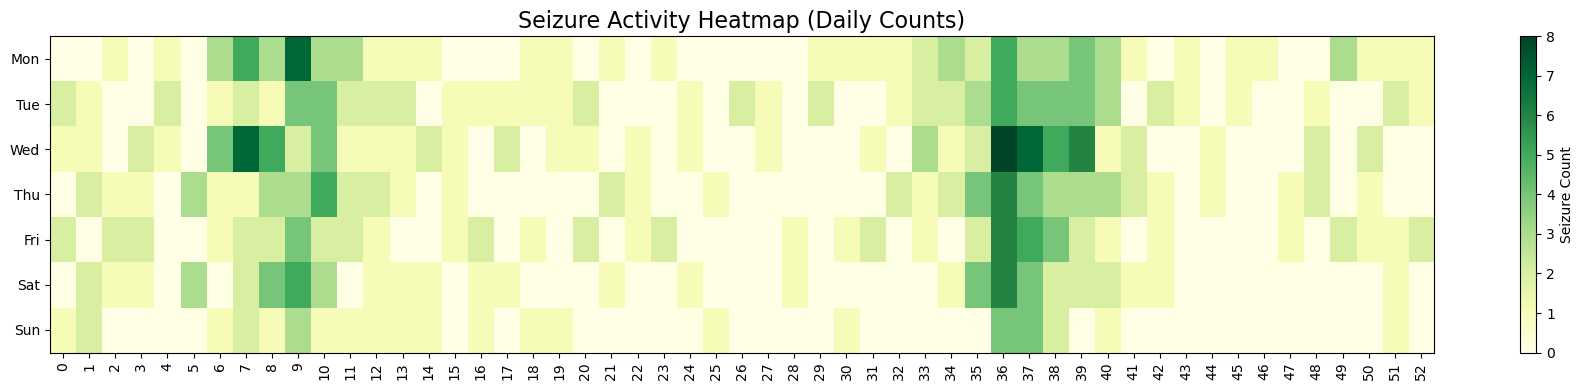

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import calendar
from datetime import datetime, timedelta

def create_heatmap(daily_seizures, start_date="2024-01-01"):
    """
    Create GitHub-style heatmap from seizure data.
    
    daily_seizures: list or array of length 364 (one value per day)
    start_date: date corresponding to index 0
    """

    # Convert to pandas Series with actual dates
    start = pd.to_datetime(start_date)
    dates = pd.date_range(start, periods=len(daily_seizures))
    s = pd.Series(daily_seizures, index=dates)

    # Create matrix: rows = Mon–Sun, cols = weeks
    s = s.resample('D').sum()  # ensure daily freq
    s = s.to_frame(name='count')
    s['dow'] = s.index.dayofweek      # 0=Mon, 6=Sun
    s['week'] = s.index.isocalendar().week

    # Fix the year-week overlap issue
    s.loc[s.index.month == 1, 'week'] -= s.loc[s.index.month == 1, 'week'].min()

    # Create pivot table
    pivot = s.pivot(index='dow', columns='week', values='count')
    
    # Replace NaN with zero
    pivot = pivot.fillna(0)

    # Plot GitHub style
    fig, ax = plt.subplots(figsize=(18, 4))
    cmap = plt.cm.YlGn  # GitHub-like green colormap

    im = ax.imshow(pivot, aspect='auto', cmap=cmap)

    # Format axes
    ax.set_yticks(range(7))
    ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=90)

    ax.set_title("Seizure Activity Heatmap (Daily Counts)", fontsize=16)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Seizure Count")

    plt.tight_layout()
    plt.show()

    return fig


# ------------------------------------------
# Example usage with your extracted data:
# ------------------------------------------

# daily_total should be your extracted array of 364 seizure counts
# Example (replace with actual):
# daily_total = np.array([...])

create_heatmap(daily_total, start_date="2024-01-01");

In [13]:
df= pd.read_csv('52_week_dashboard.csv')
df.head(3)

,Table 1,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 355,Unnamed: 356,Unnamed: 357,Unnamed: 358,Unnamed: 359,Unnamed: 360,Unnamed: 361,Unnamed: 362,Unnamed: 363,Unnamed: 364
0,Week#,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,...,51.0,51.0,51.0,52.0,52.0,52.0,52.0,52.0,52.0,52.0
1,MEDICATIONS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Lamictal,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,25.0,25.0,25.0,25.0,25.0,25.0,25.0,25.0,25.0,25.0


In [11]:
df.shape

(31, 365)

In [15]:
df1 = pd.read_csv('medications.csv')
df1.head()

,Day,Week,Medication,Dose
0,1.0,1.0,Lamictal,10.0
1,2.0,1.0,Lamictal,10.0
2,3.0,1.0,Lamictal,10.0
3,4.0,1.0,Lamictal,10.0
4,5.0,1.0,Lamictal,10.0


In [16]:
df2 = pd.read_csv('seizures.csv')
df2.head()

,Day,Week,Daily_Total_Seizures,Daily_Severe_Seizures
0,1.0,1.0,0.0,0.0
1,2.0,1.0,2.0,0.0
2,3.0,1.0,1.0,0.0
3,4.0,1.0,0.0,0.0
4,5.0,1.0,2.0,0.0


In [19]:
df3 = pd.read_csv('assessments.csv')
df3.head(3)

,Day_Index,QoL,Day_Index.1,Anxiety,Day_Index.2,Day_Index.3,Behavioral
0,1,NaN,1,NaN,1,1,NaN
1,2,NaN,2,NaN,2,2,NaN
2,3,NaN,3,NaN,3,3,NaN


In [20]:
df4 = pd.read_csv('assessments_monthly.csv')
df4.head(3)

,Month,Day
0,2024-01,7.0
1,2024-02,35.0
2,2024-03,63.0
